# N1 · 完整逆向工程: 对一个模型做一次 interp 研究

> 配套 12.7-L1 · capstone 的「把全套工具串成一次完整研究」:
> ① 装配检查 (M12 全套 src) ② 对玩具 transformer 跑**完整流程** (探针→patching→SAE),
> 产出一个连贯、因果、有证据的机制故事。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import interp_capstone as cap
cap.add_paths()
import numpy as np, torch

## 1. 装配检查: M12 全套工具 import

In [2]:
for label, ok, detail in cap.assembly_check():
    print(f"  [{'OK ' if ok else 'FAIL'}] {label:26} {detail}")
print("\n→ 探针/patching/SAE/circuits/CoT 全套工具就位 = 完整 interp 工具箱。")

  [OK ] 12.1 可hook激活的受控基座          import tiny_transformer ✓
  [OK ] 12.2 线性探针 + logit lens     import probing ✓
  [OK ] 12.3 activation patching + ablation import patching ✓
  [OK ] 12.4 SAE 解叠加               import sae ✓
  [OK ] 12.5 induction head + 归因   import circuits ✓
  [OK ] 12.6 CoT 忠实性 + w2s         import cot_probe ✓

→ 探针/patching/SAE/circuits/CoT 全套工具就位 = 完整 interp 工具箱。


## 2. 完整逆向工程流程 (探针→patching→SAE)

In [3]:
r = cap.run_full_interp(seed=0)
print(f"行为: 玩具 transformer 预测「下一个 = 当前 + 1」(任务准确率 {r['task_acc']:.2f})\n")
print(f"② 探针 (12.2):    residual 线性编码「当前值」准确率 {r['probe_acc']:.2f}  [相关线索]")
print(f"③ patching (12.3): 答案信息因果定位在位置 {r['causal_pos']} (=最后位置 {r['last_pos']})  [因果证据]")
print(f"④ SAE (12.4):     「当前值」编码为单义特征, 纯度 {r['sae_purity']:.2f} >> 原始 {r['raw_purity']:.2f}  [表示]")

行为: 玩具 transformer 预测「下一个 = 当前 + 1」(任务准确率 1.00)

② 探针 (12.2):    residual 线性编码「当前值」准确率 1.00  [相关线索]
③ patching (12.3): 答案信息因果定位在位置 7 (=最后位置 7)  [因果证据]
④ SAE (12.4):     「当前值」编码为单义特征, 纯度 0.56 >> 原始 0.15  [表示]


## 3. 连贯机制故事 (可视化证据链)

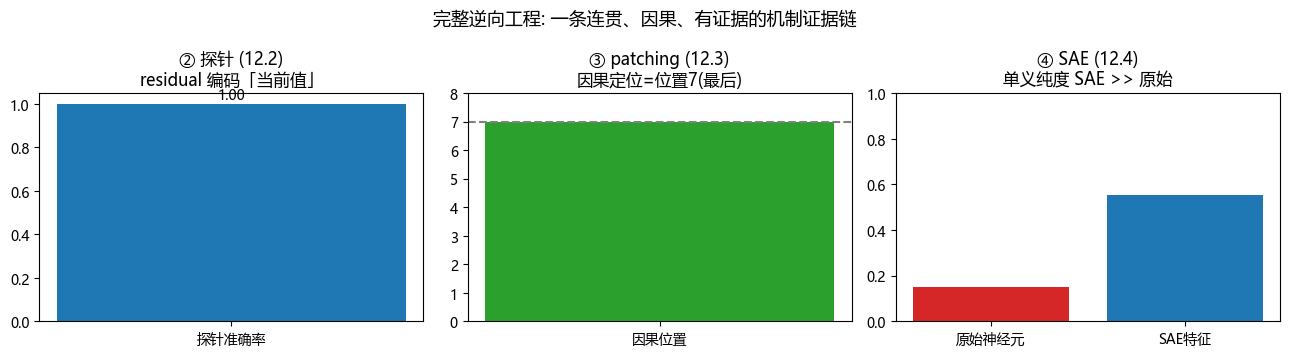

机制故事 (capstone 产物):
  模型在「最后位置」的 residual 里 (③ patching 因果定位),
  用「单义特征」编码了「当前值」(② 探针读出 + ④ SAE 解叠加),
  然后 (经某组件) +1 得出预测。
  → 每一步都有证据 (探针=相关, patching=因果, SAE=表示), 不是讲故事。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, axes = plt.subplots(1, 3, figsize=(13,3.6))
axes[0].bar(['探针准确率'], [r['probe_acc']], color='C0'); axes[0].set_ylim(0,1.05)
axes[0].set_title('② 探针 (12.2)\nresidual 编码「当前值」'); axes[0].text(0, r['probe_acc']+0.02, f"{r['probe_acc']:.2f}", ha='center')
axes[1].bar(['因果位置'], [r['causal_pos']], color='C2'); axes[1].axhline(r['last_pos'], ls='--', c='gray')
axes[1].set_title(f"③ patching (12.3)\n因果定位=位置{r['causal_pos']}(最后)"); axes[1].set_ylim(0, r['last_pos']+1)
axes[2].bar(['原始神经元','SAE特征'], [r['raw_purity'], r['sae_purity']], color=['C3','C0']); axes[2].set_ylim(0,1)
axes[2].set_title('④ SAE (12.4)\n单义纯度 SAE >> 原始')
plt.suptitle('完整逆向工程: 一条连贯、因果、有证据的机制证据链', fontsize=13); plt.tight_layout(); plt.show()
print('''机制故事 (capstone 产物):
  模型在「最后位置」的 residual 里 (③ patching 因果定位),
  用「单义特征」编码了「当前值」(② 探针读出 + ④ SAE 解叠加),
  然后 (经某组件) +1 得出预测。
  → 每一步都有证据 (探针=相关, patching=因果, SAE=表示), 不是讲故事。''')

## 4. 反思
你做了一次**完整的逆向工程**。带走:
- **完整流程**: 选行为 → 探针 (读) → patching (因果) → SAE (表示) → 机制故事。
- **证据链**: 相关 (探针) + 因果 (patching) + 表示 (SAE) 多重验证, 不是单工具/讲故事。
- **严谨贯穿**: 相关vs因果 / 充要 / 分布内 / 可证伪 (M12.3-L4 + M9.3)。
> 真模型上同理 (你 M12 全程在 gpt2/TinyLlama 上做过 induction/logit lens/CoT)。
下一步 N2: 从「会解剖」到「能推进」— interp 研究 idea 卡。